In [1]:
import geopandas as gpd
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the shapefile containing the coastal profiles
profiles = gpd.read_file(os.path.join("data", "profiles",  "perfiles_playas_limpiosCuadrantes94a120.shp"))
# Create a new column for the profile ID
profiles["profile_id"] = profiles["ID_Perfil"].astype(int)

# Load the shorelines
shorelines = gpd.read_file(os.path.join("data", "shorelines",  "LineasCosta.gpkg"),
                           layer="LineasCostaPlayas")
# Keep only the relevant columns
columns_to_keep = ["ID_LineaCosta", "Municipio", "Playa", "Fecha", "Hora", "Cuadrante", "NivelTotal"]
shorelines = shorelines[columns_to_keep + ["geometry"]]
# Filter the shorelines to keep only those where "Cuadrante" is between 94 and 120
shorelines = shorelines[(shorelines["Cuadrante"] >= 94) & (shorelines["Cuadrante"] <= 120)]

# Ensure both GeoDataFrames use the same coordinate reference system (CRS)
profiles = profiles.to_crs(shorelines.crs)
print(f"Profiles CRS: {profiles.crs}")

Profiles CRS: EPSG:25830


In [3]:
# Intersect profiles and shorelines, retaining only point intersections.
profiles_shoreline_intersections = gpd.overlay(
    profiles[["profile_id", "geometry"]],
    shorelines,
    how="intersection",
    keep_geom_type=False,
).explode(index_parts=False, ignore_index=True)
profiles_shoreline_intersections = profiles_shoreline_intersections[
    profiles_shoreline_intersections.geometry.geom_type == "Point"
].copy()

# Shapely's project() returns the along-profile distance in the CRS units (meters here).
profile_geometries = profiles.set_index("profile_id").geometry
profiles_shoreline_intersections["shoreline_position_m"] = (
    profiles_shoreline_intersections.apply(
        lambda row: profile_geometries.loc[row["profile_id"]].project(row.geometry),
        axis=1,
    )
)

profiles_shoreline_intersections = gpd.GeoDataFrame(
    profiles_shoreline_intersections[
        ["profile_id"] + columns_to_keep + ["shoreline_position_m", "geometry"]
    ],
    geometry="geometry",
    crs=profiles.crs,
)

# Create a single column for the date and time of the shoreline measurement
profiles_shoreline_intersections["datetime"] = pd.to_datetime(
    profiles_shoreline_intersections["Fecha"].astype(str)
    + " "
    + profiles_shoreline_intersections["Hora"].astype(str),
    #format="%Y%m%d %H%M",
    errors="coerce",
)
# Add the same column to the shorelines GeoDataFrame
shorelines["datetime"] = pd.to_datetime(
    shorelines["Fecha"].astype(str) + " " + shorelines["Hora"].astype(str),
    #format="%Y%m%d %H%M",
    errors="coerce",
)

In [4]:
from shoreline_evolution_viz import create_shoreline_dashboard

dashboard = create_shoreline_dashboard(
    profiles,
    shorelines,
    profiles_shoreline_intersections,
    display_widget=True,
)

In [ ]:
from utils import SmartTidalFilter

# Initialize the filter with all available parameters explicitly defined
tidal_filter = SmartTidalFilter(
    min_coverage_ratio=0.7,            # Minimum ratio of temporal coverage required (e.g., 0.7 means 70% of the global study period)
    max_gap_years=4.0,                 # Maximum continuous gap allowed between consecutive data points (in years)
    lambda_1=2.0,                      # Penalty weight for the amplitude of the tidal window (reduces topographic noise)
    lambda_2=1.5,                      # Penalty weight for losing recent data (penalizes windows that drop present years)
    window_sizes=[0.2, 0.3, 0.4, 0.5], # List of tidal window widths to test during the optimization search (in meters)
    step_size=0.1,                     # Step size to slide the tidal window across the beach's tidal range (in meters)
    beach_col="Playa",                 # DataFrame column name containing the beach or spatial unit identifier
    tide_col="NivelTotal",             # DataFrame column name containing the sea level/tidal height values
    date_col="datetime"                # DataFrame column name containing the pre-processed datetime objects
)

# Apply the filter to the geospatial dataset
filtered_data = tidal_filter.fit_transform(profiles_shoreline_intersections)

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

def visualizar_resultado_filtro(df_original, df_filtrado, profile_id, filtro_instancia, date_col="datetime"):
    """
    Genera un gráfico estático comparando los datos crudos vs filtrados y 
    muestra las métricas de la ventana de marea óptima seleccionada.
    """
    # 1. Filtrar los datos espaciales para la playa y perfil seleccionados
    df_orig_perfil = df_original[
        (df_original["profile_id"] == profile_id)
    ].copy()
    
    df_filt_perfil = df_filtrado[
        (df_filtrado["profile_id"] == profile_id)
    ].copy()
    
    if df_orig_perfil.empty:
        print(f"No se encontraron datos originales para el perfil '{profile_id}'.")
        return

    # 2. Imprimir información relevante por consola
    print(f"--- Resumen de Filtrado SmartTidal ---")
    print(f"Perfil ID: {profile_id}")
    print(f"Datos originales: {len(df_orig_perfil)} líneas")
    print(f"Datos retenidos:  {len(df_filt_perfil)} líneas ({(len(df_filt_perfil)/len(df_orig_perfil))*100:.1f}%)")
    
    # Extraer los metadatos de optimización de la instancia de la clase
    if profile_id in filtro_instancia.optimization_results:
        stats = filtro_instancia.optimization_results[profile_id]
        window = stats.get("best_window")
        score = stats.get("best_score")
        
        if window is not None:
            print(f"Ventana de marea óptima: [{window[0]:.2f} m, {window[1]:.2f} m]")
            print(f"Amplitud de ventana (Δz): {window[1]-window[0]:.2f} m")
            print(f"Puntuación de idoneidad (S): {score:.2f}")
        else:
            print("ESTADO: No se encontró ninguna ventana válida (Fallo en restricciones duras).")
    print("-" * 38)

    # 3. Identificar qué puntos exactos han sido descartados para pintarlos de gris
    # (Usamos el índice o fusionamos para separarlos limpiamente)
    if not df_filt_perfil.empty:
        df_descartados = df_orig_perfil[~df_orig_perfil.index.isin(df_filt_perfil.index)]
    else:
        df_descartados = df_orig_perfil

    # 4. Generar la figura con Matplotlib
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Pintar datos descartados (Gris + Transparencia)
    if not df_descartados.empty:
        ax.scatter(
            df_descartados[date_col], 
            df_descartados["shoreline_position_m"], 
            c='gray', 
            alpha=0.3, 
            s=40, 
            edgecolors='none',
            label='Descartados (Fuera de ventana o huecos)'
        )
        
    # Pintar datos retenidos (Rojo/Azul + Opacos)
    if not df_filt_perfil.empty:
        ax.scatter(
            df_filt_perfil[date_col], 
            df_filt_perfil["shoreline_position_m"], 
            c='#d62728', # Color rojo ladrillo para contraste
            alpha=0.9, 
            s=50, 
            edgecolors='white',
            linewidths=0.5,
            label='Retenidos (Ventana óptima)'
        )

    # Formato del gráfico
    ax.set_title(f"Impacto del Filtrado de Marea - (Perfil {profile_id})", fontsize=14, pad=15)
    ax.set_xlabel("Fecha de captura", fontsize=12)
    ax.set_ylabel("Posición Cross-shore (m)", fontsize=12)
    
    # Invertir eje Y si tus perfiles tienen el cero tierra adentro y el mar hacia valores positivos
    # ax.invert_yaxis() 
    
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Asegurar que las fechas se muestren limpias en el eje X
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

--- Resumen de Filtrado SmartTidal ---
Perfil ID: 30804
Datos originales: 784 líneas
Datos retenidos:  68 líneas (8.7%)
--------------------------------------


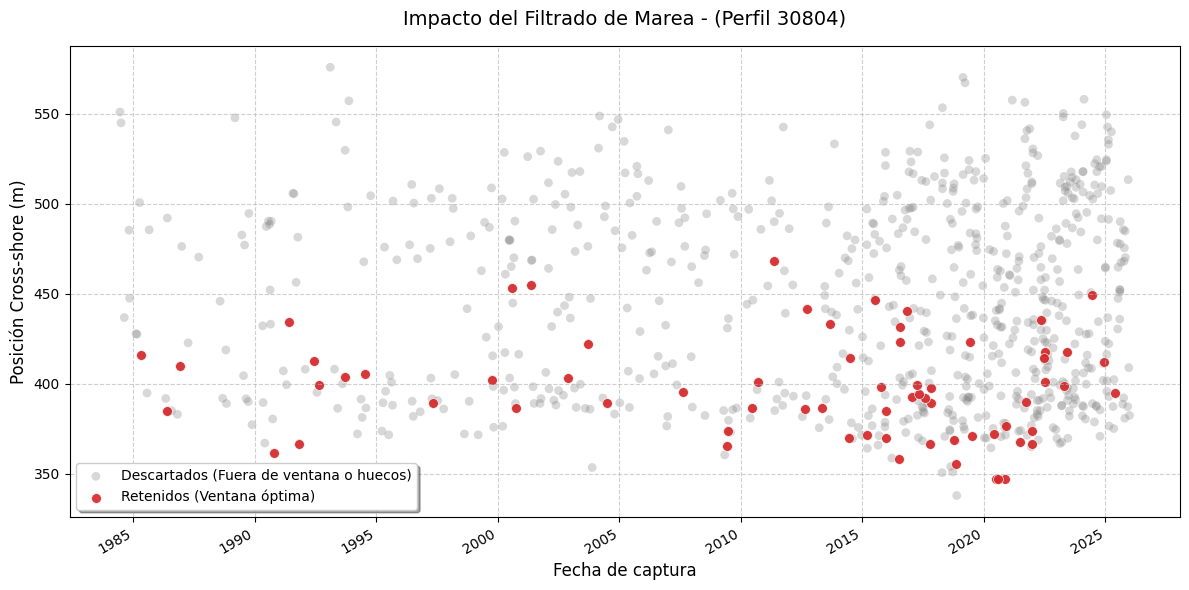

In [13]:
# Ejemplo de uso:
visualizar_resultado_filtro(
    df_original=profiles_shoreline_intersections, 
    df_filtrado=filtered_data,
    profile_id=30804,
    filtro_instancia=tidal_filter
)

In [8]:
from utils import ShorelineSmoother

# Initialize the smoother with a N-day temporal window
smoother = ShorelineSmoother(
    window='360D',               # Time-based window
    min_periods=2,               # Needs at least 2 points in those N days to compute a median
    profile_col="profile_id",
    date_col="datetime",         # Must match the datetime column outputted by the tidal filter
    pos_col="shoreline_position_m"
)

# Apply to the previously filtered dataset
smoothed_data = smoother.fit_transform(filtered_data)

In [9]:
def visualizar_resultado_suavizado(df_suavizado, profile_id, date_col="datetime", pos_col="shoreline_position_m"):
    """
    Genera un gráfico estático comparando los datos filtrados por marea (puntos) 
    frente a la serie temporal estabilizada por la mediana móvil (línea).
    """
    smoothed_col = f"{pos_col}_smoothed"
    
    # 1. Filtrar los datos para el perfil seleccionado
    df_perfil = df_suavizado[
        (df_suavizado["profile_id"] == profile_id)
    ].copy()
    
    if df_perfil.empty:
        print(f"No se encontraron datos para el perfil '{profile_id}'.")
        return

    # 2. Imprimir información básica
    print(f"--- Resumen de Estabilización ---")
    print(f"Perfil ID: {profile_id}")
    print(f"Observaciones totales: {len(df_perfil)}")
    print("-" * 33)

    # 3. Generar la figura
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Pintar datos base (filtrados por marea pero sin suavizar)
    ax.scatter(
        df_perfil[date_col], 
        df_perfil[pos_col], 
        c='#1f77b4',       # Azul tenue
        alpha=0.4, 
        s=40, 
        edgecolors='none',
        label='Posición de marea filtrada (Ruido de alta frecuencia)'
    )
    
    # Pintar la línea de tendencia suavizada (Mediana Móvil)
    ax.plot(
        df_perfil[date_col], 
        df_perfil[smoothed_col], 
        c='#d62728',       # Rojo fuerte para destacar
        linewidth=2.5,
        label='Serie suavizada (Mediana móvil)'
    )
    
    # Añadir marcadores sutiles sobre la línea suavizada
    ax.scatter(
        df_perfil[date_col], 
        df_perfil[smoothed_col], 
        c='#d62728', 
        s=15, 
        zorder=3
    )

    # Formato del gráfico
    ax.set_title(f"Efecto del Filtro de Mediana Móvil - (Perfil {profile_id})", fontsize=14, pad=15)
    ax.set_xlabel("Fecha de captura", fontsize=12)
    ax.set_ylabel("Posición Cross-shore (m)", fontsize=12)
    
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Auto-rotar las fechas para mejor legibilidad
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

--- Resumen de Estabilización ---
Perfil ID: 30804
Observaciones totales: 56
---------------------------------


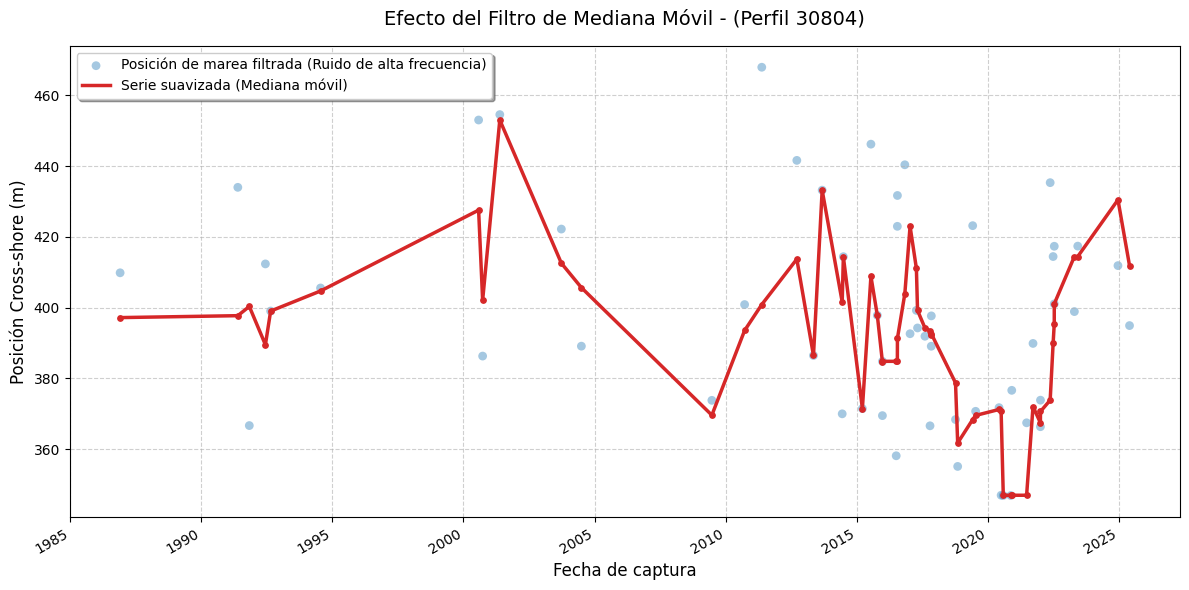

In [10]:
visualizar_resultado_suavizado(
    df_suavizado=smoothed_data,
    profile_id=30804,
)